In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

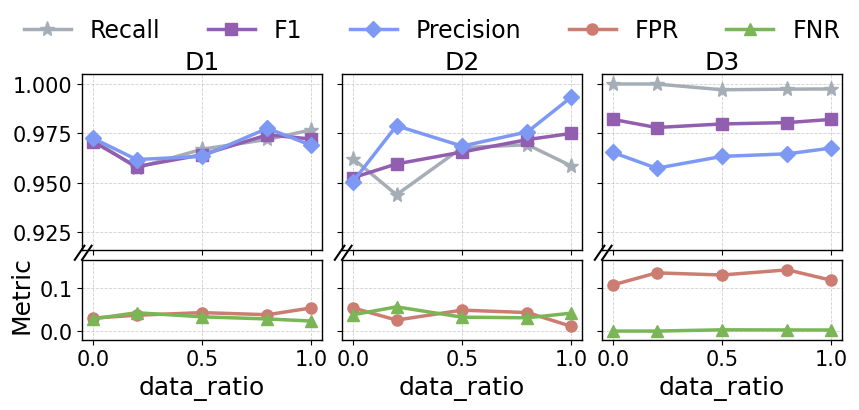

In [ ]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ============ 1) 学术会议友好参数 ============
mpl.rcParams.update({
    # 'font.family': 'serif',       # 论文字体
    "figure.figsize": (10.0, 3.2),
    "font.size": 15,
    "axes.linewidth": 1.0,
    "savefig.dpi": 300,
})

def getAvg(avg_std):
    avg = avg_std.split('±')[0]
    return float(avg)

def load_data(path):
    df = pd.read_csv(path).loc[[0,1,2,3,4], ['Supplementary_Data_Ratio','F1','Precision','Recall','FPR','FNR']]
    for c in ['F1','Precision','Recall','FPR','FNR']:
        df[c] = df[c].apply(getAvg)
    return (df['Supplementary_Data_Ratio'], df['Recall'], df['F1'], df['Precision'], df['FPR'], df['FNR'])

# ============ 2) 读取三份数据 ============
x1, R1, F11, P1, FP1, FN1 = load_data('Results/20260107_031354_sensitivity_analysis_D1.csv')
x2, R2, F12, P2, FP2, FN2 = load_data('Results/20260107_035518_sensitivity_analysis_D2.csv')
x3, R3, F13, P3, FP3, FN3 = load_data('Results/20260107_031357_sensitivity_analysis_D3.csv')

# ============ 3) 绘图函数：两段纵轴 ============
def add_break(ax, where="bottom", dx=0.02, dy=0.04, lw=1.5):
    trans = ax.transAxes
    y = -0.015 if where == "bottom" else 1.00
    for offset in [0.05, 0.08]:
        ax.plot([-0.06 + offset - dx, -0.06 + offset + dx],
                [y - dy, y + dy],
                transform=trans, clip_on=False, linewidth=lw, color="black")

def plot_panel(fig, left, x, R, F1, P, FPR, FNR, title, tag, show_ylabel=True):
    bottom, width = 0.22, 0.24
    h_low, h_top, gap = 0.25, 0.55, 0.03

    ax_top = fig.add_axes([left, bottom + h_low + gap, width, h_top])
    ax_low = fig.add_axes([left, bottom, width, h_low], sharex=ax_top)

    # 上层范围
    ax_top.set_ylim(0.916, 1.005)
    # 下层范围
    ax_low.set_ylim(-0.02, 0.165)

    # 绘制主指标
    ax_top.plot(x, R,  marker="*", markersize=11., linewidth=2.5, label="Recall", color="#A5AEB7")
    ax_top.plot(x, F1, marker="s", markersize=8., linewidth=2.5, label="F1", color="#925EB0")
    ax_top.plot(x, P,  marker="D", markersize=8., linewidth=2.5, label="Precision", color="#7E99F4")

    # 绘制误差指标
    ax_low.plot(x, FPR, marker="o", markersize=8., linewidth=2.5, label="FPR", color="#CC7C71")
    ax_low.plot(x, FNR, marker="^", markersize=8., linewidth=2.5, label="FNR", color="#7AB656")

    # 样式
    for ax in (ax_top, ax_low):
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
        ax.set_xlim(-0.05, 1.05)
    ax_top.tick_params(axis="x", labelbottom=False)
    ax_low.set_xlabel("data_ratio", fontsize=18)

    # y 轴标签仅第一列保留
    if show_ylabel:
        ax_top.set_ylabel("Metric", labelpad=10, fontsize=18)
        ax_top.yaxis.set_label_coords(-0.2, -0.25)
    else:
        ax_top.set_yticklabels([])
        ax_low.set_yticklabels([])

    # 断裂符号
    add_break(ax_top, "bottom")

    # 标题与标签
    ax_top.set_title(title, pad=2)
    # fig.text(left + width/2, 0.02, tag, ha="center", va="center")

    return ax_top

# ============ 4) 绘制三列面板 ============
fig = plt.figure()

ax1 = plot_panel(fig, 0.08, x1, R1, F11, P1, FP1, FN1, "D1", "(a)", show_ylabel=True)
ax2 = plot_panel(fig, 0.34, x2, R2, F12, P2, FP2, FN2, "D2", "(b)", show_ylabel=False)
ax3 = plot_panel(fig, 0.60, x3, R3, F13, P3, FP3, FN3, "D3", "(c)", show_ylabel=False)

# 图例
handles, labels = ax1.get_legend_handles_labels()
handles2 = [
    plt.Line2D([], [], marker="o", linewidth=2.5, markersize=8, label="FPR", color="#CC7C71"),
    plt.Line2D([], [], marker="^", linewidth=2.5, markersize=8, label="FNR", color="#7AB656"),
]
fig.legend(handles + handles2, labels + ["FPR", "FNR"],
           loc="upper center", ncol=5, bbox_to_anchor=(0.43, 1.29), frameon=False, fontsize=17)

plt.savefig("Result_Figures/Fig5_DataRatio_D1D2D3.pdf", bbox_inches="tight")
plt.show()


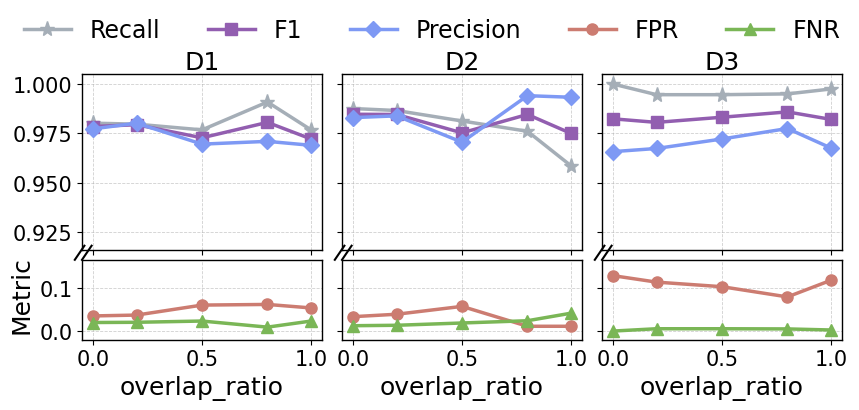

In [ ]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ============ 1) 学术会议友好参数 ============
mpl.rcParams.update({
    # 'font.family': 'serif',       # 论文字体
    "figure.figsize": (10.0, 3.2),
    "font.size": 15,
    "axes.linewidth": 1.0,
    "savefig.dpi": 300,
})

def getAvg(avg_std):
    avg = avg_std.split('±')[0]
    return float(avg)

def load_data(path):
    df = pd.read_csv(path).loc[[5,6,7,8,4], ['Overlap_Ratio','F1','Precision','Recall','FPR','FNR']]
    for c in ['F1','Precision','Recall','FPR','FNR']:
        df[c] = df[c].apply(getAvg)
    return (df['Overlap_Ratio'], df['Recall'], df['F1'], df['Precision'], df['FPR'], df['FNR'])

# ============ 2) 读取三份数据 ============
x1, R1, F11, P1, FP1, FN1 = load_data('Results/20260107_031354_sensitivity_analysis_D1.csv')
x2, R2, F12, P2, FP2, FN2 = load_data('Results/20260107_035518_sensitivity_analysis_D2.csv')
x3, R3, F13, P3, FP3, FN3 = load_data('Results/20260107_031357_sensitivity_analysis_D3.csv')

# ============ 3) 绘图函数：两段纵轴 ============
def add_break(ax, where="bottom", dx=0.02, dy=0.04, lw=1.5):
    trans = ax.transAxes
    y = -0.015 if where == "bottom" else 1.00
    for offset in [0.05, 0.08]:
        ax.plot([-0.06 + offset - dx, -0.06 + offset + dx],
                [y - dy, y + dy],
                transform=trans, clip_on=False, linewidth=lw, color="black")

def plot_panel(fig, left, x, R, F1, P, FPR, FNR, title, tag, show_ylabel=True):
    bottom, width = 0.22, 0.24
    h_low, h_top, gap = 0.25, 0.55, 0.03

    ax_top = fig.add_axes([left, bottom + h_low + gap, width, h_top])
    ax_low = fig.add_axes([left, bottom, width, h_low], sharex=ax_top)

    # 上层范围
    ax_top.set_ylim(0.916, 1.005)
    # 下层范围
    ax_low.set_ylim(-0.02, 0.165)

    # 绘制主指标
    ax_top.plot(x, R,  marker="*", markersize=11., linewidth=2.5, label="Recall", color="#A5AEB7")
    ax_top.plot(x, F1, marker="s", markersize=8., linewidth=2.5, label="F1", color="#925EB0")
    ax_top.plot(x, P,  marker="D", markersize=8., linewidth=2.5, label="Precision", color="#7E99F4")

    # 绘制误差指标
    ax_low.plot(x, FPR, marker="o", markersize=8., linewidth=2.5, label="FPR", color="#CC7C71")
    ax_low.plot(x, FNR, marker="^", markersize=8., linewidth=2.5, label="FNR", color="#7AB656")

    # 样式
    for ax in (ax_top, ax_low):
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
        ax.set_xlim(-0.05, 1.05)
    ax_top.tick_params(axis="x", labelbottom=False)
    ax_low.set_xlabel("overlap_ratio", fontsize=18)

    # y 轴标签仅第一列保留
    if show_ylabel:
        ax_top.set_ylabel("Metric", labelpad=10, fontsize=18)
        ax_top.yaxis.set_label_coords(-0.2, -0.25)
    else:
        ax_top.set_yticklabels([])
        ax_low.set_yticklabels([])

    # 断裂符号
    add_break(ax_top, "bottom")

    # 标题与标签
    ax_top.set_title(title, pad=2)
    # fig.text(left + width/2, 0.02, tag, ha="center", va="center")

    return ax_top

# ============ 4) 绘制三列面板 ============
fig = plt.figure()

ax1 = plot_panel(fig, 0.08, x1, R1, F11, P1, FP1, FN1, "D1", "(a)", show_ylabel=True)
ax2 = plot_panel(fig, 0.34, x2, R2, F12, P2, FP2, FN2, "D2", "(b)", show_ylabel=False)
ax3 = plot_panel(fig, 0.60, x3, R3, F13, P3, FP3, FN3, "D3", "(c)", show_ylabel=False)

# 图例
handles, labels = ax1.get_legend_handles_labels()
handles2 = [
    plt.Line2D([], [], marker="o", linewidth=2.5, markersize=8, label="FPR", color="#CC7C71"),
    plt.Line2D([], [], marker="^", linewidth=2.5, markersize=8, label="FNR", color="#7AB656"),
]
fig.legend(handles + handles2, labels + ["FPR", "FNR"],
           loc="upper center", ncol=5, bbox_to_anchor=(0.43, 1.29), frameon=False, fontsize=17)

plt.savefig("Result_Figures/Fig6_OverlapRatio_D1D2D3.pdf", bbox_inches="tight")
plt.show()


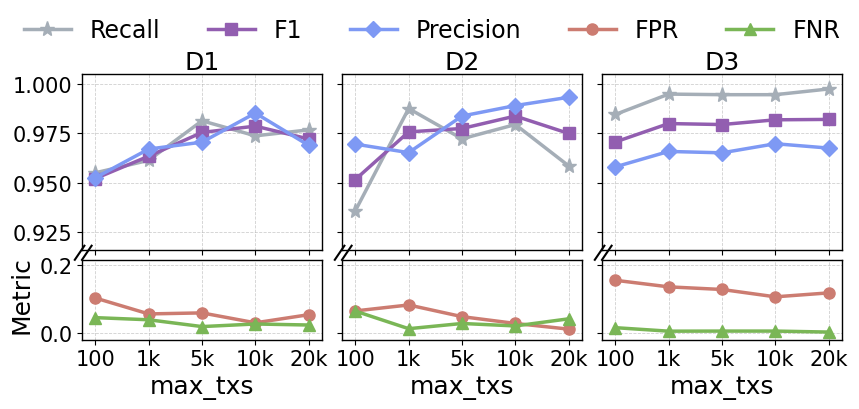

In [ ]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ============ 1) 学术会议友好参数 ============
mpl.rcParams.update({
    # 'font.family': 'serif',       # 论文字体
    "figure.figsize": (10.0, 3.2),
    "font.size": 15,
    "axes.linewidth": 1.0,
    "savefig.dpi": 300,
})

def getAvg(avg_std):
    avg = avg_std.split('±')[0]
    return float(avg)

def load_data(path):
    df = pd.read_csv(path).loc[[9,10,11,12,4], ['Overlap_Ratio','F1','Precision','Recall','FPR','FNR']]
    for c in ['F1','Precision','Recall','FPR','FNR']:
        df[c] = df[c].apply(getAvg)
    return (df['Overlap_Ratio'], df['Recall'], df['F1'], df['Precision'], df['FPR'], df['FNR'])

# ============ 2) 读取三份数据 ============
x1, R1, F11, P1, FP1, FN1 = load_data('Results/20260107_031354_sensitivity_analysis_D1.csv')
x2, R2, F12, P2, FP2, FN2 = load_data('Results/20260107_035518_sensitivity_analysis_D2.csv')
x3, R3, F13, P3, FP3, FN3 = load_data('Results/20260107_031357_sensitivity_analysis_D3.csv')

# ============ 3) 绘图函数：两段纵轴 ============
def add_break(ax, where="bottom", dx=0.02, dy=0.04, lw=1.5):
    trans = ax.transAxes
    y = -0.015 if where == "bottom" else 1.00
    for offset in [0.05, 0.08]:
        ax.plot([-0.06 + offset - dx, -0.06 + offset + dx],
                [y - dy, y + dy],
                transform=trans, clip_on=False, linewidth=lw, color="black")

def plot_panel(fig, left, x, R, F1, P, FPR, FNR, title, tag, show_ylabel=True):
    bottom, width = 0.22, 0.24
    h_low, h_top, gap = 0.25, 0.55, 0.03

    ax_top = fig.add_axes([left, bottom + h_low + gap, width, h_top])
    ax_low = fig.add_axes([left, bottom, width, h_low], sharex=ax_top)

    # 上层范围
    ax_top.set_ylim(0.916, 1.005)
    # 下层范围
    ax_low.set_ylim(-0.02, 0.215)

    # 绘制主指标
    ax_top.plot(x, R,  marker="*", markersize=11., linewidth=2.5, label="Recall", color="#A5AEB7")
    ax_top.plot(x, F1, marker="s", markersize=8., linewidth=2.5, label="F1", color="#925EB0")
    ax_top.plot(x, P,  marker="D", markersize=8., linewidth=2.5, label="Precision", color="#7E99F4")

    # 绘制误差指标
    ax_low.plot(x, FPR, marker="o", markersize=8., linewidth=2.5, label="FPR", color="#CC7C71")
    ax_low.plot(x, FNR, marker="^", markersize=8., linewidth=2.5, label="FNR", color="#7AB656")

    # 样式
    for ax in (ax_top, ax_low):
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
        ax.set_xlim(-0.25, 4.25)
    ax_top.set_xticks([0, 1, 2, 3, 4])
    ax_low.set_xticks([0, 1, 2, 3, 4])
    ax_low.set_xticklabels(['100', '1k', '5k', '10k', '20k'], fontsize=15)
    ax_top.tick_params(axis="x", labelbottom=False)
    ax_low.set_xlabel("max_txs", fontsize=18)

    # y 轴标签仅第一列保留
    if show_ylabel:
        ax_top.set_ylabel("Metric", labelpad=10, fontsize=18)
        ax_top.yaxis.set_label_coords(-0.2, -0.25)
    else:
        ax_top.set_yticklabels([])
        ax_low.set_yticklabels([])

    # 断裂符号
    add_break(ax_top, "bottom")

    # 标题与标签
    ax_top.set_title(title, pad=2)
    # fig.text(left + width/2, 0.02, tag, ha="center", va="center")

    return ax_top

# ============ 4) 绘制三列面板 ============
fig = plt.figure()

ax1 = plot_panel(fig, 0.08, np.arange(0, 5, 1), R1, F11, P1, FP1, FN1, "D1", "(a)", show_ylabel=True)
ax2 = plot_panel(fig, 0.34, np.arange(0, 5, 1), R2, F12, P2, FP2, FN2, "D2", "(b)", show_ylabel=False)
ax3 = plot_panel(fig, 0.60, np.arange(0, 5, 1), R3, F13, P3, FP3, FN3, "D3", "(c)", show_ylabel=False)

# 图例
handles, labels = ax1.get_legend_handles_labels()
handles2 = [
    plt.Line2D([], [], marker="o", linewidth=2.5, markersize=8, label="FPR", color="#CC7C71"),
    plt.Line2D([], [], marker="^", linewidth=2.5, markersize=8, label="FNR", color="#7AB656"),
]
fig.legend(handles + handles2, labels + ["FPR", "FNR"],
           loc="upper center", ncol=5, bbox_to_anchor=(0.43, 1.29), frameon=False, fontsize=17)

plt.savefig("Result_Figures/Fig7_MaxTxs_D1D2D3.pdf", bbox_inches="tight")
plt.show()


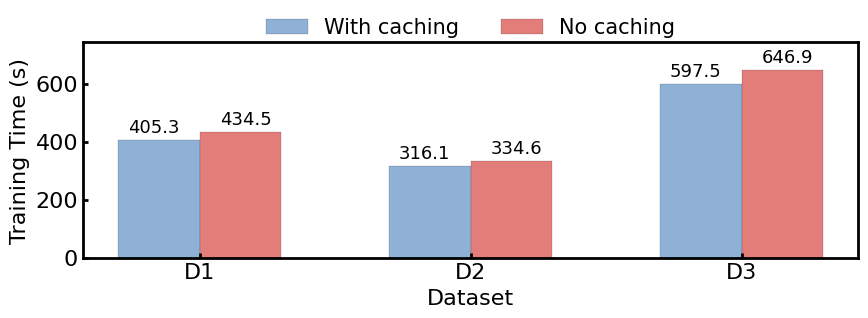

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ========= 全局风格（对齐示例图） =========
mpl.rcParams.update({
    "font.size": 16,
    "axes.linewidth": 2.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 2.0,
    "ytick.major.width": 2.0,
})

# ========= 数据 =========
labels = ["D1", "D2", "D3"]
with_cache = [405.27, 316.05, 597.50]
no_cache   = [434.51, 334.62, 646.85]

x = np.arange(len(labels))
width = 0.30

# ========= 配色（完全对齐示例） =========
color_with = "#8FB1D6"   # 蓝
color_no   = "#E27D7A"   # 红

fig, ax = plt.subplots(figsize=(10, 2.8))

# ========= 柱子 =========
b1 = ax.bar(x - width/2, with_cache, width,
            color=color_with, label="With caching", edgecolor="black", linewidth=0.1)

b2 = ax.bar(x + width/2, no_cache, width,
            color=color_no, label="No caching", edgecolor="black", linewidth=0.1)

# ========= 轴 & 标签 =========
ax.set_ylabel("Training Time (s)")
ax.set_xlabel("Dataset")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, max(no_cache) * 1.15)

# 保留上、右边框（示例图就是这样）
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)

# ========= 图例 =========
ax.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.2), frameon=False, fontsize=15)

# ========= 柱顶数值 =========
for i, bars in enumerate((b1, b2)):
    for r in bars:
        h = r.get_height()
        # 左边的往左偏，右边的往右偏
        offset = -0.02 if i == 0 else 0.02
        ax.text(
            r.get_x() + r.get_width() / 2 + offset,
            h + max(no_cache) * 0.02,
            f"{h:.1f}",
            ha="center",
            va="bottom",
            fontsize=13
        )

plt.savefig("Result_Figures/Fig_Train_cache.pdf", bbox_inches="tight")
plt.show()


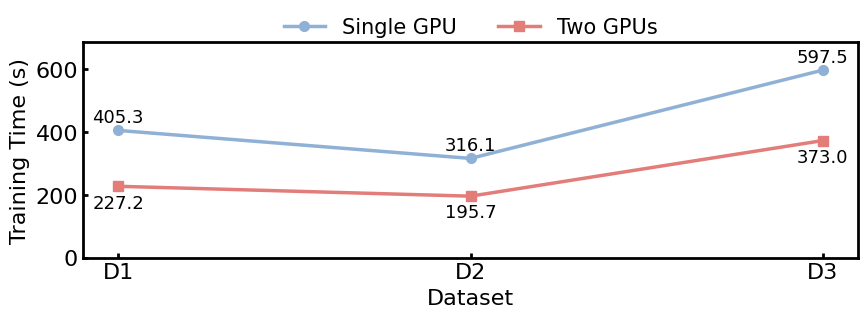

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ========= 全局风格（与柱状图完全一致） =========
mpl.rcParams.update({
    "font.size": 16,
    "axes.linewidth": 2.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 2.0,
    "ytick.major.width": 2.0,
})

# ========= 数据 =========
labels = ["D1", "D2", "D3"]
single_gpu = [405.27, 316.05, 597.50]
two_gpus   = [227.21, 195.72, 372.98]

x = np.arange(len(labels))

# ========= 配色（完全不变） =========
color_single = "#8FB1D6"   # 蓝
color_two    = "#E27D7A"   # 红

fig, ax = plt.subplots(figsize=(10, 2.8))

# ========= 折线 =========
l1, = ax.plot(
    x, single_gpu,
    marker='o', markersize=7,
    linewidth=2.5,
    color=color_single,
    label="Single GPU"
)

l2, = ax.plot(
    x, two_gpus,
    marker='s', markersize=7,
    linewidth=2.5,
    color=color_two,
    label="Two GPUs"
)

# ========= 轴 & 标签 =========
ax.set_ylabel("Training Time (s)")
ax.set_xlabel("Dataset")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, max(single_gpu) * 1.15)

# 保留上、右边框
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)

# ========= 图例（与柱状图完全一致） =========
ax.legend(
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.2),
    frameon=False,
    fontsize=15
)

# ========= 数值标注（同步柱状图风格） =========
for i in range(len(x)):
    # Single GPU（稍微往上）
    ax.text(
        x[i],
        single_gpu[i] + max(single_gpu) * 0.02,
        f"{single_gpu[i]:.1f}",
        ha="center",
        va="bottom",
        fontsize=13
    )

    # Two GPUs（稍微往下，避免重叠）
    ax.text(
        x[i],
        two_gpus[i] - max(single_gpu) * 0.04,
        f"{two_gpus[i]:.1f}",
        ha="center",
        va="top",
        fontsize=13
    )

plt.savefig("Result_Figures/Fig_Train_multigpu.pdf", bbox_inches="tight")
plt.show()


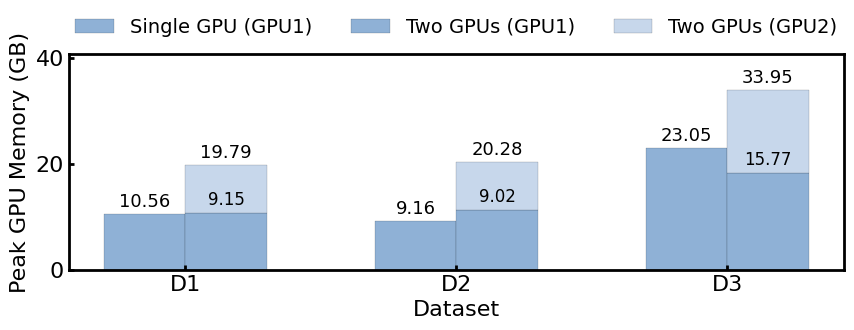

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ========= 全局风格（与你定稿图完全一致） =========
mpl.rcParams.update({
    "font.size": 16,
    "axes.linewidth": 2.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 2.0,
    "ytick.major.width": 2.0,
})

# ========= 数据 =========
labels = ["D1", "D2", "D3"]

# 单 GPU（只有 GPU1）
single_gpu = np.array([10.56, 9.16, 23.05])

# 双 GPU（GPU1 + GPU2）
two_gpu_1 = np.array([10.64, 11.26, 18.18])   # GPU1
two_gpu_2 = np.array([9.15, 9.02, 15.77])   # GPU2

x = np.arange(len(labels))
width = 0.30

# ========= 配色（同一色系，论文安全） =========
color_gpu1 = "#8FB1D6"   # GPU1
color_gpu2 = "#C7D7EB"   # GPU2（更浅）

fig, ax = plt.subplots(figsize=(10, 2.8))

# ========= 单 GPU 柱 =========
b_single = ax.bar(
    x - width/2,
    single_gpu,
    width,
    label="GPU1 (Single GPU)",
    color=color_gpu1,
    edgecolor="black",
    linewidth=0.1
)

# ========= 双 GPU 堆叠柱 =========
b_two_1 = ax.bar(
    x + width/2,
    two_gpu_1,
    width,
    label="GPU1 (Two GPUs)",
    color=color_gpu1,
    edgecolor="black",
    linewidth=0.1
)

b_two_2 = ax.bar(
    x + width/2,
    two_gpu_2,
    width,
    bottom=two_gpu_1,
    label="GPU2 (Two GPUs)",
    color=color_gpu2,
    edgecolor="black",
    linewidth=0.1
)

# ========= 坐标轴 =========
ax.set_ylabel("Peak GPU Memory (GB)")
ax.set_xlabel("Dataset")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, max(single_gpu.max(), (two_gpu_1 + two_gpu_2).max()) * 1.20)

ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)

# ========= 图例（清晰、不拥挤） =========
ax.legend(
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.25),
    frameon=False,
    fontsize=14
)

# ========= 数值标注 =========
for i in range(len(labels)):
    # Single GPU
    ax.text(
        x[i] - width/2,
        single_gpu[i] + 0.6,
        f"{single_gpu[i]:.2f}",
        ha="center", va="bottom", fontsize=13
    )

    # Two GPUs total
    total = two_gpu_1[i] + two_gpu_2[i]
    ax.text(
        x[i] + width/2,
        total + 0.6,
        f"{total:.2f}",
        ha="center", va="bottom", fontsize=13
    )

    # Two GPUs (GPU2, 下方)
    ax.text(
        x[i] + width/2,
        two_gpu_1[i] + 2.5,
        f"{two_gpu_2[i]:.2f}",
        ha="center", va="center", fontsize=12, color="black"
    )

plt.savefig("Result_Figures/Fig_GPU_Memory_Stacked.pdf", bbox_inches="tight")
plt.show()
